In [1]:
print ("Day 5 start")

Day 5 start


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel("Ticker", axis=1)

data['daily_return'] = data['Close'].pct_change()

[*********************100%***********************]  1 of 1 completed


In [3]:
data['rolling_vol'] = data['daily_return'].rolling(21).std() * (252**0.5)
print(data['rolling_vol'].dropna().head())

2025-02-04    0.139541
2025-02-05    0.134041
2025-02-06    0.133253
2025-02-07    0.130959
2025-02-10    0.132486
Name: rolling_vol, dtype: float64


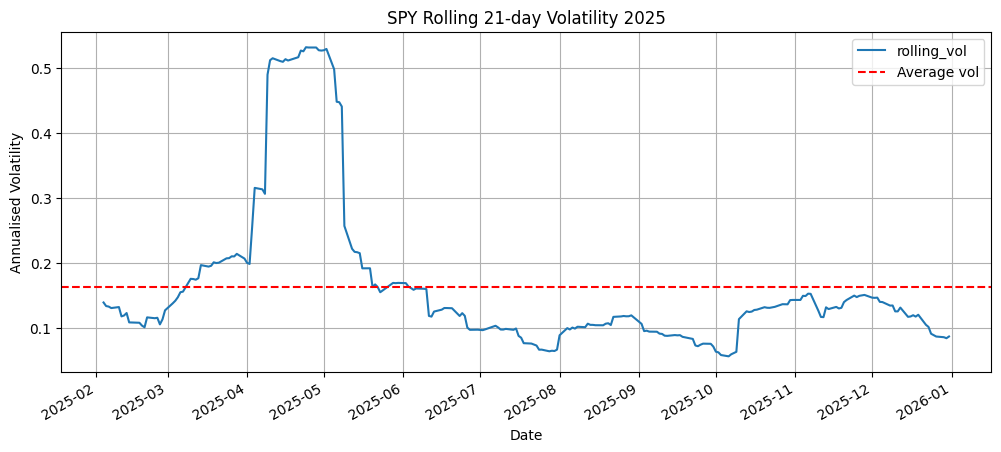

In [4]:
data['rolling_vol'].plot(figsize=(12,5))
plt.title("SPY Rolling 21-day Volatility 2025")
plt.ylabel("Annualised Volatility")
plt.xlabel("Date")
plt.axhline (y=data['rolling_vol'].mean(), color='r',
             linestyle='--', label='Average vol')
plt.legend()
plt.grid(True)
plt.show()